$$\frac{\partial^2 u}{\partial t^2} = \frac{\partial^2 u}{\partial x^2} \quad ; -1 \le x \le 1$$

Initial Conditions
$$u(x, 0) = f(x) = \sin(\pi x),$$

$$u_t(x, 0) = g(x) = 0$$

with the boundary conditions

$$u(-1,t) = u(1,t) = 0.$$

The analytical solution is given in $[17]$ as

$$u(x,t) = \frac{1}{2}(\sin(\pi(x+t)) + \sin(\pi(x-t))).$$

In [ ]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from SG_solver import rbf_matrix, second_divided_difference, d2_L_W2
from fractal_SG_solver import ddphi, H5_dd
from alpha_fractal_function import alpha_fractalize_second_derivative

In [3]:
# Paper Example 1 parameters.
a = -1.0
b = 1.0
#######################
K = 8
s = 0.8
c = 0.027 
################
h = 0.01
tau = 0.01
################
T = 1
###################


$$x_i = a + \frac{i(b-a)}{n}, \quad i = 0, \ldots, n,$$

and $N = \frac{n}{K}$ , where K is a positive integer. The choice of
the interpolation centers $\{x_{k_j}\}_{j=1}^N$ as follows

$$x_{k_1} = x_1, \quad x_{k_N} = x_{n-1},$$

$$x_{k_j} = a + \frac{(j-1)(b-a)}{N}, \quad j = 2, \dots, N-1.$$

In [4]:
n = (b - a) / h

if n != int(n):
    raise ValueError("h must divide b-a exactly.")

n = int(n)

if n % K != 0:
    raise ValueError("n must be divisible by K because the paper defines N = n / K.")

N = n // K
Nt = int(round(T / tau))

x = np.linspace(a, b, n + 1)

# Interpolation center indices k_j, j = 1,...,N
k_idx = np.concatenate(([1], K * np.arange(1, N - 1), [n - 1])).astype(int)

xk = x[k_idx]
xkj = []
for j in range(1, N+1):
    if j == 1:
        value = float(x[1])
        xkj.append(value)

    elif 1 < j < N:
        value = a + ((j - 1) * (b - a)) / N
        xkj.append(value)
    elif j == N:
        value = float(x[n - 1])
        xkj.append(value)

The analytical solution is given in $[17]$ as

$$u(x,t) = \frac{1}{2}(\sin(\pi(x+t)) + \sin(\pi(x-t))).$$

In [5]:
def exact_u(x, t):
    return 0.5 * (np.sin(np.pi * (x + t)) + np.sin(np.pi * (x - t)))

At $t=0$, 
$$u(x,0) = \sin(\pi x).$$

In [6]:
# Storage for time and space levels
# U[d, i] ≈ u(x_i, d*tau), d=0,...,Nt

U = np.zeros((Nt + 2, len(x)))
print(np.shape(U))

# Initial condition at t=0
U[0, :] = np.sin(np.pi * x)  # exact_u(x, 0)

(102, 201)


The boundary conditions

$$u(-1,t) = u(1,t) = 0.$$

In [7]:
U[0, 0]  = 0.0
U[0, -1] = 0.0

$$
\sum_{j=1}^{N} \alpha_j \varphi(|x_{k_i}-x_{k_j}|) =
\frac{2u_{k_i+1}^{n}}{(x_{k_i+1}-x_{k_i})(x_{k_i+1}-x_{k_i-1})}
+ \frac{2u_{k_i-1}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i-1})}
- \frac{2u_{k_i}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i})}.
\tag{19}$$

The right side is the same three-point second divided-difference formula from Eq. 15, and applied at the current time-level values $u_n$.
$$ \alpha_m = \sum_{i=1}^{N}\left[A^{-1}\right]_{mi}\left(\frac{2u_{k_i+1}^{n}}{(x_{k_i+1}-x_{k_i})(x_{k_i+1}-x_{k_i-1})} + \frac{2u_{k_i-1}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i-1})} - \frac{2u_{k_i}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i})} \right),\\ \quad m=1,\ldots,N,$$
$$A_{ij}=\varphi(|x_{k_i}-x_{k_j}|)$$

In [8]:
# Build approximation of u_xx at t=0
A0 = rbf_matrix(xk, s)
rhs0 = []
for kj in k_idx:
    rhs0.append(second_divided_difference(x, U[0, :], kj))
rhs0 = np.asarray(rhs0)

alpha0 = np.linalg.solve(A0, rhs0)

# print("alpha0:", alpha0)

$$u_{k}^{n+1} = 2u_{k}^{n} - u_{k}^{n-1} + \tau^{2} \left[ \sum_{j=1}^{N} \alpha_{j} \varphi(x_{k} - x_{k_{j}}) + \sum_{i=0}^{n} \left( u_{i}^{n} - \sum_{j=1}^{N} \alpha_{j} \sqrt{s^{2} + (x_{i} - x_{k_{j}})^{2}} \right) \psi_{i}''(x_{k}) \right], \tag{18}$$
$$u_{k}^{n+1} = 2u_{k}^{n} - u_{k}^{n-1} + \tau^{2}*\left(L_{w_{2}}u_{k}^{n}\right)''$$

Given initial condition: 
$$u_t(x, 0) = g(x) = 0$$
Using Central Difference:
$$u_{k}^{-1}= u_{k}^{1}$$
We have
$$u_{k}^{1} = u_{k}^{0} + \frac{1}{2}*\tau^{2}*\left(L_{w_{2}}u_{k}^{n}\right)''$$


In [9]:
# for 1st time step
uxx0 = np.zeros(len(x))
for i in range(len(x)):
    uxx0[i] = d2_L_W2(i, x, U[0, :], xk, alpha0, s, c)
   
# Since g(x)=0
U[1, :] = U[0, :] + 0.5 * tau**2 * uxx0
U[1, 0]  = 0.0
U[1, -1] = 0.0

In [10]:
# Time stepping:
# u_k^{n+1} = 2u_k^n - u_k^{n-1} + tau^2 * (L_w2 u_k^d)''
#-------------------------------------------------------------

for d in tqdm(range(1, Nt + 1), desc="Time stepping", unit="step"):
    A = rbf_matrix(xk, s)
    rhs_d = np.asarray([second_divided_difference(x, U[d], kj) for kj in k_idx])
    alpha1 = np.linalg.solve(A, rhs_d)

    uxx = np.zeros(len(x))
    for i in range( len(x)):
        uxx[i] = d2_L_W2(i, x, U[d], xk, alpha1, s, c)

    U[d + 1, :] = 2.0 * U[d, :] - U[d - 1, :] + tau**2 * uxx

    # Dirichlet boundary conditions
    U[d + 1, 0] = 0.0
    U[d + 1, -1] = 0.0

Time stepping:   0%|          | 0/100 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 100/100 [00:42<00:00,  2.35step/s]


In [11]:
# # Fractal parameters
# f_alpha = [0.022, -0.008, -0.025, -0.025, -0.008, 0.022]
# # f_alpha = [0, 0, 0, 0, 0, 0]
# # f_alpha = [0.0001, -0.00004, -0.00012, -0.00012, -0.00004, 0.0001]
# n_subintervals = 6
# f_x = np.linspace(a, b, n_subintervals + 1)
# n_points = 1000
# n_iter = 2000
# fractal_dd = build_fractal_second_derivative(f_x, c, f_alpha, n_points, n_iter)

In [12]:
# L = b - a                 # physical interval length
# z_left = -L
# z_right = L

# f_alpha = [0.022, -0.008, -0.025, -0.025, -0.008, 0.022]
# n_subintervals = 6
# f_x = np.linspace(z_left, z_right, n_subintervals + 1)
# # n_points = 1000
# n_iter = 8

# fractal_dd = build_fractal_second_derivative(f_x, c, f_alpha, n_iter)

In [23]:
# f_alpha = [-0.0002, 0, -0.0001, -0.0001, 0, -0.0002]
# f_alpha = [0.002, -0.008, -0.005, -0.005, -0.008, 0.002]
f_alpha = [0.0005, 0.002, 0.0005, 0.0005, 0.002, 0.0005]
n_subintervals = 6 #len(f_alpha) #len(f_alpha)
n_iter = 2
X = np.linspace(a, b, n_subintervals + 1)
fractal_dd = alpha_fractalize_second_derivative(ddphi, H5_dd, -2, 2, n_subintervals, f_alpha, n_iter)

In [24]:
# Initial condition at t=0
f_U = np.zeros((Nt + 2, len(x)))
print(np.shape(f_U))
f_U[0, :] = np.sin(np.pi * x)  # initial condition at t=0

f_U[0, 0]  = 0.0
f_U[0, -1] = 0.0

f_uxx0 = np.zeros(len(x))
for i in range(len(x)):
    # uxx0[i] = d2_L_W2(i, x, U[0, :], xk, alpha0, s, c)
    f_uxx0[i] = d2_fractal_L_W2(i, x, f_U[0, :], xk, alpha0, s, fractal_dd)

# Since g(x)=0
f_U[1, :] = f_U[0, :] + 0.5 * tau**2 * f_uxx0
f_U[1, 0]  = 0.0
f_U[1, -1] = 0.0

(102, 201)


In [25]:
# Time stepping:
# u_k^{n+1} = 2u_k^n - u_k^{n-1} + tau^2 * (L_w2 u_k^d)''
# using d instead of n for time level index to avoid confusion with spatial index k.
for d in tqdm(range(1, Nt + 1), desc="Time stepping", unit="step"):
    A = rbf_matrix(xk, s)
    rhs_d = np.asarray([second_divided_difference(x, f_U[d], kj) for kj in k_idx])
    alpha2 = np.linalg.solve(A, rhs_d)

    f_uxx = np.zeros(len(x))
    for i in range( len(x)):
        f_uxx[i] = d2_fractal_L_W2(i, x, f_U[d], xk, alpha2, s, fractal_dd)

    f_U[d + 1, :] = 2.0 * f_U[d, :] - f_U[d - 1, :] + tau**2 * f_uxx

    # Dirichlet boundary conditions
    f_U[d + 1, 0] = 0.0
    f_U[d + 1, -1] = 0.0

Time stepping: 100%|██████████| 100/100 [02:03<00:00,  1.23s/step]


In [30]:
# Final solution and error at time T
u_num = U[Nt +1 , :]
f_u_num = f_U[Nt, :]
u_ex = exact_u(x, T )  # Exact solution at T+tau because of the central difference initialization)

err = -(u_ex - u_num)
f_err = -(u_ex - f_u_num)

abs_err = np.abs(err)
f_abs_err = np.abs(f_err)

Linf = np.max(abs_err)
f_Linf = np.max(f_abs_err)

RMS = np.sqrt(np.mean(abs_err**2))
f_RMS = np.sqrt(np.mean(f_abs_err**2))

Linf_difference = Linf - f_Linf
RMS_difference = RMS - f_RMS
# print(u_num)

print("Linf error =", Linf)
print("f_Linf error =", f_Linf)
print("RMS error  =", RMS)
print("f_RMS error  =", f_RMS)
print("Linf difference =", Linf_difference)
print("RMS difference =", RMS_difference)

Linf error = 0.0004994613174513773
f_Linf error = 0.00010620949653761258
RMS error  = 0.0003516240829043753
f_RMS error  = 2.8124198132923856e-05
Linf difference = 0.00039325182091376476
RMS difference = 0.00032349988477145146


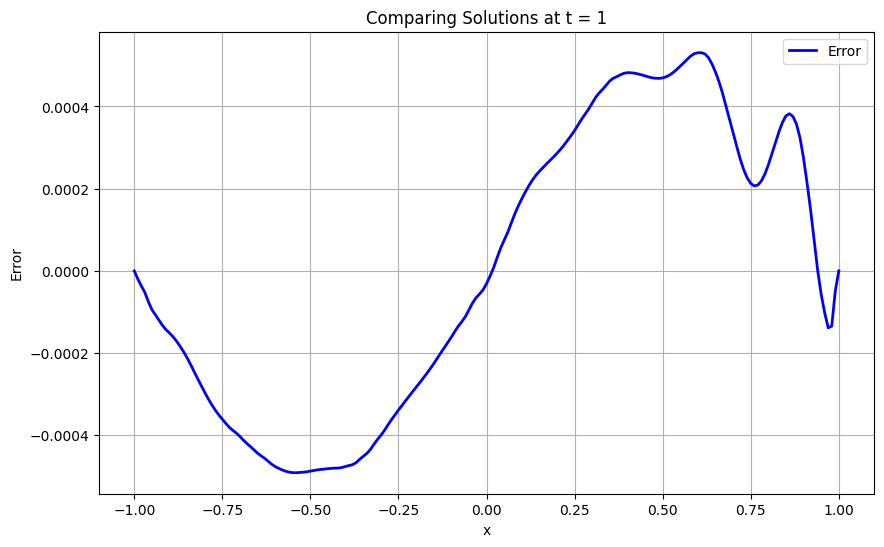

In [31]:
comp_error = u_num - f_u_num
plt.figure(figsize=(10, 6))
plt.plot(x, comp_error, label="Error", color="blue", linewidth=2)
plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Comparing Solutions at t = {T}")
plt.grid(True)
plt.legend()
plt.show()

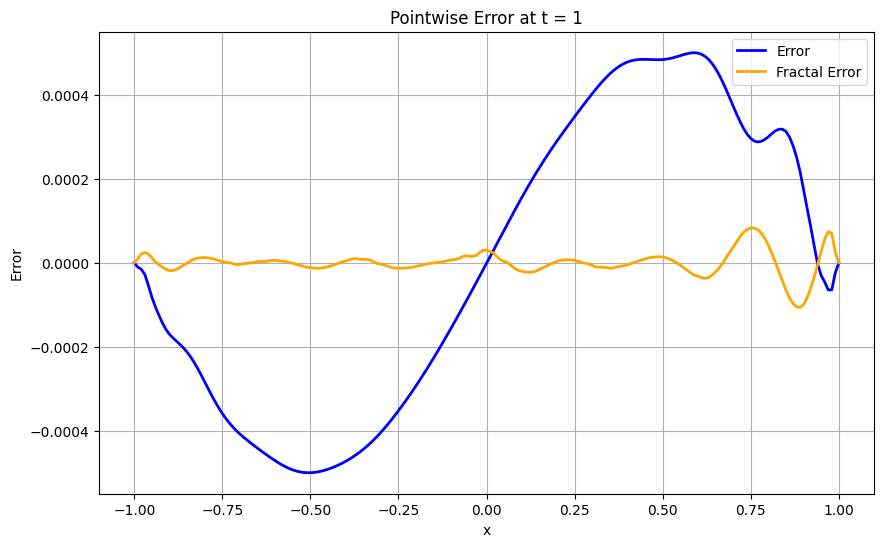

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(x, err, label="Error", color="blue", linewidth=2)
plt.plot(x, f_err, label="Fractal Error", color="orange", linewidth=2)
plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Pointwise Error at t = {T}")
plt.grid(True)
plt.legend()
plt.savefig("Error_Comparison_SG_equation.png", format="png")
plt.show()

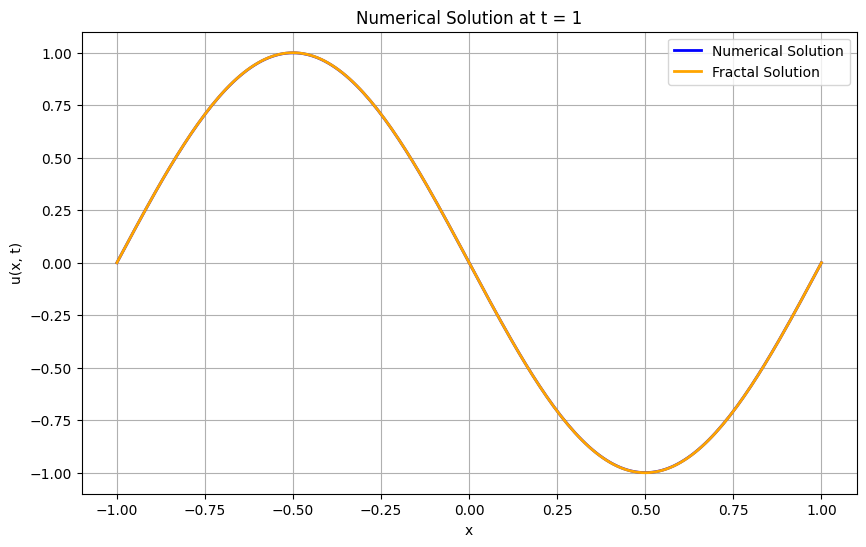

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(x, u_num, label="Numerical Solution", color="blue", linewidth=2)
plt.plot(x, f_u_num, label="Fractal Solution", color="orange", linewidth=2)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title(f"Numerical Solution at t = {T}")
plt.grid(True)
plt.legend()
plt.show()
